# Laboratorium 11 — Differential Transformer

W tym laboratorium modyfikujemy klasyczny Transformer Encoder z Lab 10, zastępując standardowy mechanizm self-attention warstwą **Differential Attention** (Microsoft Research, 2024).

## Motywacja

W zwykłym multi-head attention każda głowica generuje **jedną macierz** wag uwagi po softmax:

$$A = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d}}\right)$$

Problem: softmax nadaje niezerowe wagi nawet nieistotnym tokenom — szum rozsiewa się po całej sekwencji.

**Differential Attention** działa jak *wzmacniacz różnicowy* ze świata elektroniki: tworzymy **dwie** niezależne mapy uwagi i odejmujemy je od siebie. Szum koreluje między nimi, więc się kasuje; sygnał — nie:

$$A_{\text{diff}} = \text{softmax}\!\left(\frac{Q_1 K_1^T}{\sqrt{d}}\right) - \lambda \cdot \text{softmax}\!\left(\frac{Q_2 K_2^T}{\sqrt{d}}\right)$$

gdzie $\lambda$ to wyuczalny skalar inicjalizowany na małą wartość (~0.05–0.1).

Autorzy pokazują, że model: lepiej wydobywa informacje z długich kontekstów, redukuje halucynacje i jest bardziej odporny na nadmiarowe tokeny.

> **Źródło:** Tianhao Liu et al., *Differential Transformer*, ICLR 2025 — [arxiv.org/abs/2410.05258](https://arxiv.org/abs/2410.05258)


## 1. Dane i konfiguracja

Importy i załadowanie IMDB — identycznie jak w Lab 10.

In [12]:
import ssl, certifi, torch, torch.nn as nn, numpy as np, math, matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz', num_words=None, skip_top=0,
    maxlen=None, seed=113, start_char=1, oov_char=2, index_from=3
)

MAX_LEN    = 200
VOCAB_SIZE = max(max(s) for s in x_train) + 1
EMBED_DIM  = 64
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'VOCAB_SIZE={VOCAB_SIZE}, device={DEVICE}')


VOCAB_SIZE=88587, device=cuda


In [13]:
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels, max_len=None):
        self.labels = torch.tensor(labels, dtype=torch.float32)
        if max_len:
            sequences = [s[:max_len] for s in sequences]
        self.sequences = [torch.tensor(s, dtype=torch.long) for s in sequences]
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

def collate_padded(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True, padding_value=0)
    return padded, lengths, torch.stack(labels)

train_loader = DataLoader(IMDBDataset(x_train, y_train, MAX_LEN), batch_size=64, shuffle=True,  collate_fn=collate_padded)
test_loader  = DataLoader(IMDBDataset(x_test,  y_test,  MAX_LEN), batch_size=64, shuffle=False, collate_fn=collate_padded)

x, lengths, y = next(iter(train_loader))
print(f'batch: {x.shape}, lengths: {lengths[:5]}')


batch: torch.Size([64, 200]), lengths: tensor([100, 165, 149, 144, 169])


## 2. Komponenty pomocnicze z Lab 10

Positional Encoding i pętla treningowa są takie same jak poprzednio — przepisujemy je bez zmian.

In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [15]:
import os

def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cpu',
                run_name=None, checkpoint_dir='checkpoints', resume=True):
    """
    Trenuje model z opcjonalnym checkpointowaniem.

    run_name        : nazwa runu — jeśli podana, zapisuje/wznawia z checkpoints/{run_name}.pth
    checkpoint_dir  : katalog na checkpointy (tworzony automatycznie)
    resume          : wznów trening z ostatniego checkpointu jeśli istnieje
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    start_epoch = 0

    ckpt_path = None
    if run_name:
        os.makedirs(checkpoint_dir, exist_ok=True)
        ckpt_path = os.path.join(checkpoint_dir, f'{run_name}.pth')

    if resume and ckpt_path and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        history    = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
        print(f'[checkpoint] wznowiono {run_name} — epoka {start_epoch}/{epochs}')
        if start_epoch >= epochs:
            print('[checkpoint] trening już ukończony, pomijam.')
            return history

    for epoch in range(start_epoch, epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for x, lengths, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(x, lengths)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            correct    += ((out > 0) == y.bool()).sum().item()
            total      += y.size(0)

        train_loss = total_loss / total
        train_acc  = correct / total

        model.eval()
        correct_t, total_t = 0, 0
        with torch.no_grad():
            for x, lengths, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x, lengths)
                correct_t += ((out > 0) == y.bool()).sum().item()
                total_t   += y.size(0)

        test_acc = correct_t / total_t
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f'Epoch {epoch+1}/{epochs} | loss: {train_loss:.4f} | '
              f'train acc: {train_acc:.3f} | test acc: {test_acc:.3f}')

        if ckpt_path:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
            }, ckpt_path)

    return history


def load_checkpoint(model, run_name, checkpoint_dir='checkpoints', device=None):
    """Ładuje wagi i historię z checkpointu do istniejącego obiektu modelu. Zwraca history."""
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    ckpt_path = os.path.join(checkpoint_dir, f'{run_name}.pth')
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device).eval()
    print(f'[checkpoint] załadowano {run_name} (epoka {ckpt["epoch"]+1})')
    return ckpt['history']


def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    xs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(xs, history['train_loss'], marker='o', color='steelblue')
    axes[0].set_title('Strata treningowa')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('BCE Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(xs, history['train_acc'], marker='o', color='seagreen', label='train')
    axes[1].plot(xs, history['test_acc'],  marker='s', color='tomato',   label='test')
    axes[1].set_title('Dokładność')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Finalna dokładność testowa: {history["test_acc"][-1]:.3f}')


## 3. Implementacja Differential Attention

### Jak działa pojedyncza głowica?

Standardowa głowica multi-head attention:
- projektuje wejście na $Q, K, V$ (każdy o wymiarze $d = d_{\text{model}}/h$)
- liczy $A = \text{softmax}(QK^T/\sqrt{d})$, wynik: $AV$

Głowica **Differential Attention**:
- **podwaja** wymiar projekcji $Q$ i $K$ — do $2d$ na głowicę
- **split po mnożeniu**: $Q = [Q_1, Q_2]$, $K = [K_1, K_2]$ (każdy $d$)
- liczy **dwie** mapy uwagi i odejmuje:

$$\text{DiffAttn}(X) = \left[\text{softmax}\!\left(\frac{Q_1 K_1^T}{\sqrt{d}}\right) - \lambda \cdot \text{softmax}\!\left(\frac{Q_2 K_2^T}{\sqrt{d}}\right)\right] V$$

- $V$ pozostaje niepodzielone (wymiar $2d$), bo jest tylko nośnikiem wartości
- $\lambda$ jest **wyuczalnym** skalarem (oddzielny dla każdej głowicy), inicjalizowanym do ~0.05–0.1
- Paper stosuje **RMSNorm** po DiffAttn przed projekcją wyjściową

Aby zachować ten sam łączny koszt co vanilla MHA, używamy **h/2 głowic**
(każda ma 2× szerszy Q/K niż w vanilla).


In [16]:
class DifferentialAttention(nn.Module):
    """
    Differential Multi-Head Self-Attention.

    d_model       : wymiar embeddingu (musi byc podzielny przez 2*num_heads)
    num_heads     : liczba glosic diff attention (= num_heads_vanilla / 2)
    dropout       : dropout na wagach uwagi
    lambda_init   : wartosc startowa lambda
    """
    def __init__(self, d_model: int, num_heads: int = 4,
                 dropout: float = 0.1, lambda_init: float = 0.05):
        super().__init__()
        assert d_model % (2 * num_heads) == 0, \
            'd_model musi byc podzielne przez 2*num_heads'

        self.num_heads = num_heads
        self.d_head    = d_model // num_heads   # rozmiar jednej glosicy dla V
        self.d_half    = self.d_head // 2       # rozmiar podprzestrzeni Q1/Q2/K1/K2

        # Q i K projkeja: d_model -> d_model (czyli 2*d_half na glosice)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        # Lambda — oddzielna dla kazdej glosicy
        self.lambda_ = nn.Parameter(torch.full((num_heads,), lambda_init))

        # RMSNorm po diff attention (przed W_o), jak w paperze
        self.norm = nn.RMSNorm(d_model)

        self.attn_drop = nn.Dropout(dropout)
        self.scale     = self.d_half ** -0.5

    def forward(self, x: torch.Tensor,
                key_padding_mask=None) -> torch.Tensor:
        """
        x                : (B, T, d_model)
        key_padding_mask : (B, T) bool, True = ignoruj token
        """
        B, T, _ = x.shape
        h, dh, dq = self.num_heads, self.d_head, self.d_half

        # Projekcje
        Q = self.W_q(x).view(B, T, h, 2 * dq).transpose(1, 2)  # (B, h, T, 2*dq)
        K = self.W_k(x).view(B, T, h, 2 * dq).transpose(1, 2)
        V = self.W_v(x).view(B, T, h, dh).transpose(1, 2)       # (B, h, T, dh)

        # Split na Q1/Q2 i K1/K2
        Q1, Q2 = Q[..., :dq], Q[..., dq:]
        K1, K2 = K[..., :dq], K[..., dq:]

        # Dwie mapy uwagi
        A1 = (Q1 @ K1.transpose(-2, -1)) * self.scale  # (B, h, T, T)
        A2 = (Q2 @ K2.transpose(-2, -1)) * self.scale

        if key_padding_mask is not None:
            mask = key_padding_mask[:, None, None, :]   # (B, 1, 1, T)
            A1 = A1.masked_fill(mask, float('-inf'))
            A2 = A2.masked_fill(mask, float('-inf'))

        A1 = torch.softmax(A1, dim=-1)
        A2 = torch.softmax(A2, dim=-1)

        # Differential: A1 - lambda * A2
        lam = self.lambda_.view(1, h, 1, 1).clamp(0.0, 1.0)
        A_diff = self.attn_drop(A1 - lam * A2)           # (B, h, T, T)

        # Kontekst + RMSNorm
        out = A_diff @ V                                  # (B, h, T, dh)
        out = out.transpose(1, 2).contiguous().view(B, T, h * dh)  # (B, T, d_model)
        out = self.norm(out)

        return self.W_o(out)


### DiffTransformerEncoderLayer

Struktura identyczna z `nn.TransformerEncoderLayer`, ale zamiast `nn.MultiheadAttention` używamy `DifferentialAttention`. Używamy Pre-Norm dla stabilności treningu.


In [17]:
class DiffTransformerEncoderLayer(nn.Module):
    """Pre-Norm encoder layer z Differential Attention."""
    def __init__(self, d_model: int, num_diff_heads: int = 4,
                 dim_feedforward: int = 256, dropout: float = 0.1,
                 lambda_init: float = 0.05):
        super().__init__()

        self.self_attn = DifferentialAttention(
            d_model=d_model, num_heads=num_diff_heads,
            dropout=dropout, lambda_init=lambda_init
        )

        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, src_key_padding_mask=None) -> torch.Tensor:
        x = x + self.self_attn(self.norm1(x), key_padding_mask=src_key_padding_mask)
        x = x + self.ff(self.norm2(x))
        return x


### DifferentialTransformerClassifier

Drop-in replacement dla `TransformerClassifier` z Lab 10. API jest identyczne — ta sama pętla treningowa działa bez zmian.

In [18]:
class DifferentialTransformerClassifier(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 64,
                 num_diff_heads: int = 4, dim_feedforward: int = 256,
                 num_layers: int = 3, dropout: float = 0.1,
                 max_len: int = 500, lambda_init: float = 0.05):
        super().__init__()
        self.cls_token    = nn.Parameter(torch.randn(1, 1, d_model))
        self.embedding    = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len + 1, dropout=dropout)

        self.layers = nn.ModuleList([
            DiffTransformerEncoderLayer(
                d_model=d_model, num_diff_heads=num_diff_heads,
                dim_feedforward=dim_feedforward, dropout=dropout,
                lambda_init=lambda_init
            )
            for _ in range(num_layers)
        ])

        self.norm       = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor, lengths=None) -> torch.Tensor:
        B = x.size(0)
        x   = self.embedding(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.pos_encoding(x)

        mask = None
        if lengths is not None:
            T    = x.size(1)
            mask = torch.zeros(B, T, dtype=torch.bool, device=x.device)
            for i, l in enumerate(lengths):
                if l + 1 < T:
                    mask[i, l + 1:] = True

        for layer in self.layers:
            x = layer(x, src_key_padding_mask=mask)

        x = self.norm(x)
        return self.classifier(x[:, 0, :]).squeeze(-1)


# Test ksztaltow
diff_model = DifferentialTransformerClassifier(vocab_size=VOCAB_SIZE)
x_b, l_b, y_b = next(iter(train_loader))
print(f'Wyjscie: {diff_model(x_b, l_b).shape}  (oczekiwane: torch.Size([64]))')
print(f'Parametrow: {sum(p.numel() for p in diff_model.parameters()):,}')


Wyjscie: torch.Size([64])  (oczekiwane: torch.Size([64]))
Parametrow: 5,819,213


## 4. Trening — model bazowy (Differential Transformer)

Trenujemy domyslna konfiguracje na zbiorze IMDB.

Parametrów: 5,819,213
Epoch 1/30 | loss: 0.5597 | train acc: 0.694 | test acc: 0.791
Epoch 2/30 | loss: 0.4086 | train acc: 0.816 | test acc: 0.823
Epoch 3/30 | loss: 0.3345 | train acc: 0.856 | test acc: 0.836
Epoch 4/30 | loss: 0.2799 | train acc: 0.885 | test acc: 0.837
Epoch 5/30 | loss: 0.2387 | train acc: 0.905 | test acc: 0.845
Epoch 6/30 | loss: 0.2063 | train acc: 0.921 | test acc: 0.835
Epoch 7/30 | loss: 0.1752 | train acc: 0.933 | test acc: 0.842
Epoch 8/30 | loss: 0.1531 | train acc: 0.943 | test acc: 0.842
Epoch 9/30 | loss: 0.1288 | train acc: 0.952 | test acc: 0.842
Epoch 10/30 | loss: 0.1095 | train acc: 0.963 | test acc: 0.837
Epoch 11/30 | loss: 0.0972 | train acc: 0.967 | test acc: 0.836
Epoch 12/30 | loss: 0.0828 | train acc: 0.972 | test acc: 0.832
Epoch 13/30 | loss: 0.0753 | train acc: 0.974 | test acc: 0.827
Epoch 14/30 | loss: 0.0636 | train acc: 0.978 | test acc: 0.830
Epoch 15/30 | loss: 0.0615 | train acc: 0.979 | test acc: 0.828
Epoch 16/30 | loss: 0.0562 

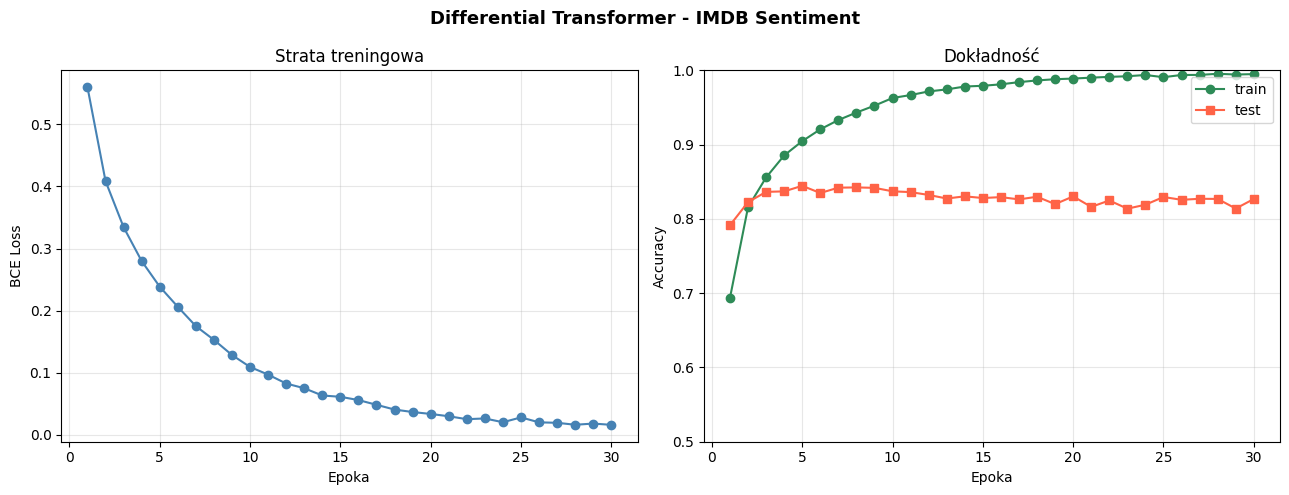

Finalna dokładność testowa: 0.827


In [19]:
diff_model = DifferentialTransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=EMBED_DIM,       # 64
    num_diff_heads=4,        # 4 głowice diff = ekwiwalent 8 głowic vanilla
    dim_feedforward=256,
    num_layers=3,
    dropout=0.1,
    max_len=MAX_LEN,
    lambda_init=0.05
)
print(f'Parametrów: {sum(p.numel() for p in diff_model.parameters()):,}')

history_diff = train_model(
    diff_model, train_loader, test_loader, epochs=30, device=DEVICE,
    run_name='base_differential'
)
plot_history(history_diff, title='Differential Transformer - IMDB Sentiment')


## 5. Eksperymenty

Seria ukierunkowanych eksperymentow badajacych wplyw kluczowych hiperparametrow i decyzji projektowych Differential Transformer.

### Eksperyment 1 — Wplyw inicjalizacji lambda

Parametr $\lambda$ kontroluje jak mocno druga mapa uwagi tlumi pierwsza.
- $\lambda \approx 0$ — model zachowuje sie jak zwykly Transformer (brak odejmowania)
- $\lambda \approx 1$ — maksymalne tlumienie szumu, ryzyko zbyt agresywnego kasowania informacji

Testujemy: `lambda_init` w {0.0, 0.05, 0.1, 0.3}



=== lambda_init = 0.0 (run: exp1_lambda_0p0) ===
[checkpoint] wznowiono exp1_lambda_0p0 — epoka 1/10
Epoch 2/10 | loss: 0.4015 | train acc: 0.820 | test acc: 0.814
Epoch 3/10 | loss: 0.3306 | train acc: 0.860 | test acc: 0.832
Epoch 4/10 | loss: 0.2838 | train acc: 0.884 | test acc: 0.842
Epoch 5/10 | loss: 0.2389 | train acc: 0.905 | test acc: 0.842
Epoch 6/10 | loss: 0.2128 | train acc: 0.918 | test acc: 0.843
Epoch 7/10 | loss: 0.1769 | train acc: 0.932 | test acc: 0.842
Epoch 8/10 | loss: 0.1530 | train acc: 0.942 | test acc: 0.841
Epoch 9/10 | loss: 0.1351 | train acc: 0.950 | test acc: 0.835
Epoch 10/10 | loss: 0.1112 | train acc: 0.960 | test acc: 0.828

=== lambda_init = 0.05 (run: exp1_lambda_0p05) ===
Epoch 1/10 | loss: 0.5668 | train acc: 0.689 | test acc: 0.792
Epoch 2/10 | loss: 0.4016 | train acc: 0.817 | test acc: 0.828
Epoch 3/10 | loss: 0.3313 | train acc: 0.856 | test acc: 0.833
Epoch 4/10 | loss: 0.2868 | train acc: 0.882 | test acc: 0.836
Epoch 5/10 | loss: 0.2412 

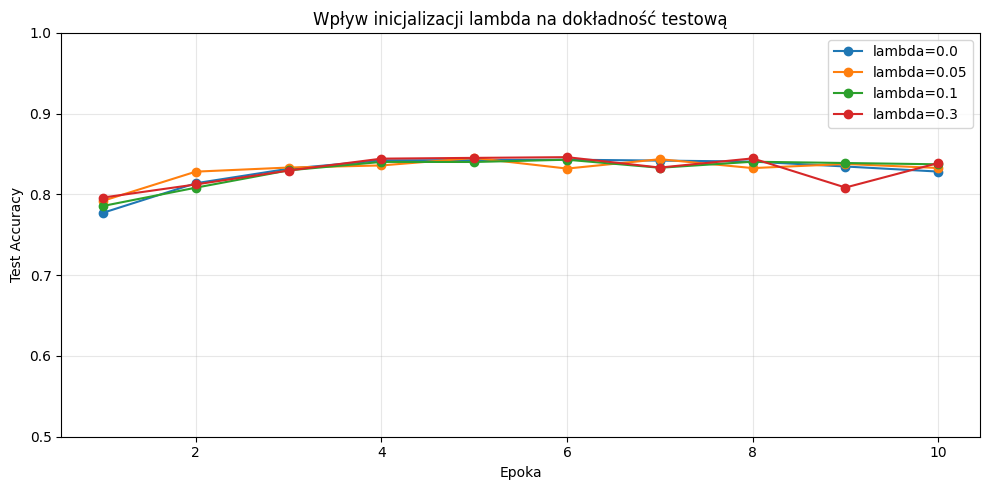


Finalne test acc:
  lambda_init=0.0: 0.8282
  lambda_init=0.05: 0.8327
  lambda_init=0.1: 0.8372
  lambda_init=0.3: 0.8388


In [21]:
lambda_values = [0.0, 0.05, 0.1, 0.3]
results_lambda = {}

for lam in lambda_values:
    run = f'exp1_lambda_{str(lam).replace(".", "p")}'
    print(f'\n=== lambda_init = {lam} (run: {run}) ===')
    m = DifferentialTransformerClassifier(
        vocab_size=VOCAB_SIZE, d_model=EMBED_DIM, num_diff_heads=4,
        dim_feedforward=256, num_layers=3, dropout=0.1,
        max_len=MAX_LEN, lambda_init=lam
    )
    h = train_model(m, train_loader, test_loader, epochs=10, device=DEVICE, run_name=run)
    results_lambda[lam] = h['test_acc']

fig, ax = plt.subplots(figsize=(10, 5))
for lam, accs in results_lambda.items():
    ax.plot(range(1, len(accs)+1), accs, marker='o', label=f'lambda={lam}')
ax.set_title('Wpływ inicjalizacji lambda na dokładność testową')
ax.set_xlabel('Epoka')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nFinalne test acc:')
for lam, accs in results_lambda.items():
    print(f'  lambda_init={lam}: {accs[-1]:.4f}')


### Eksperyment 2 — Liczba glosic Differential Attention

W vanilla MHA standardowo uzywamy 4 lub 8 glosic. W Differential Attention kazda glosica generuje dwie mapy, wiec mamy `num_diff_heads` glosic differential = `2 * num_diff_heads` map uwagi lacznie.

Testujemy: `num_diff_heads` w {1, 2, 4, 8} przy stalym `d_model=64`.

Uwaga: dla `num_diff_heads=8` kazda glosica ma `d_half = 64 / (2*8) = 4` — juz bardzo mala przestrzen uwagi.



=== num_diff_heads = 1 (run: exp2_heads_1) ===
  Parametrów: 5,819,204
Epoch 1/10 | loss: 0.5761 | train acc: 0.679 | test acc: 0.783
Epoch 2/10 | loss: 0.4214 | train acc: 0.807 | test acc: 0.824
Epoch 3/10 | loss: 0.3437 | train acc: 0.853 | test acc: 0.823
Epoch 4/10 | loss: 0.2909 | train acc: 0.878 | test acc: 0.822
Epoch 5/10 | loss: 0.2477 | train acc: 0.899 | test acc: 0.814
Epoch 6/10 | loss: 0.2133 | train acc: 0.915 | test acc: 0.832
Epoch 7/10 | loss: 0.1813 | train acc: 0.930 | test acc: 0.841
Epoch 8/10 | loss: 0.1544 | train acc: 0.942 | test acc: 0.839
Epoch 9/10 | loss: 0.1266 | train acc: 0.954 | test acc: 0.839
Epoch 10/10 | loss: 0.1077 | train acc: 0.962 | test acc: 0.835

=== num_diff_heads = 2 (run: exp2_heads_2) ===
  Parametrów: 5,819,207
Epoch 1/10 | loss: 0.5680 | train acc: 0.686 | test acc: 0.794
Epoch 2/10 | loss: 0.4050 | train acc: 0.817 | test acc: 0.824
Epoch 3/10 | loss: 0.3336 | train acc: 0.858 | test acc: 0.834
Epoch 4/10 | loss: 0.2827 | train ac

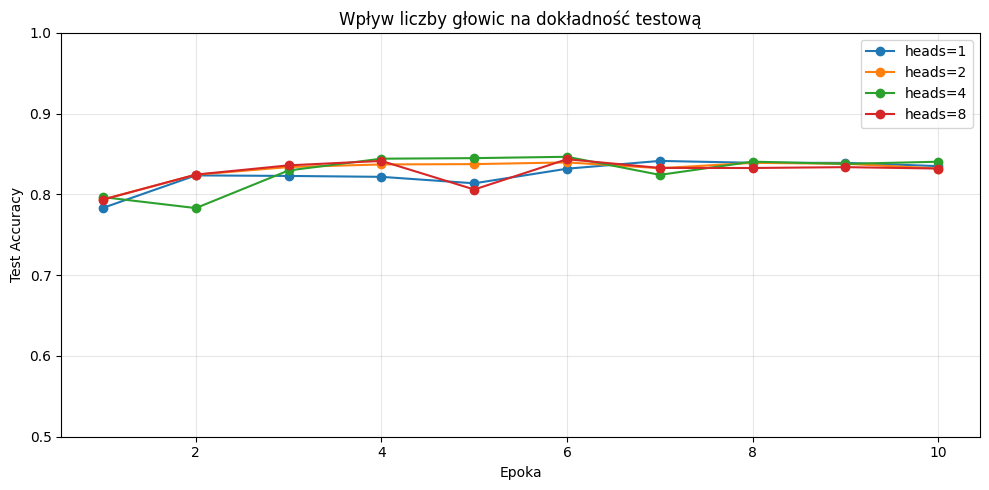


Finalne test acc:
  num_diff_heads=1: 0.8350
  num_diff_heads=2: 0.8320
  num_diff_heads=4: 0.8404
  num_diff_heads=8: 0.8320


In [22]:
head_values = [1, 2, 4, 8]
results_heads = {}

for nh in head_values:
    if EMBED_DIM % (2 * nh) != 0:
        print(f'Pomijam nh={nh}: EMBED_DIM={EMBED_DIM} nie dzieli się przez {2*nh}')
        continue
    run = f'exp2_heads_{nh}'
    print(f'\n=== num_diff_heads = {nh} (run: {run}) ===')
    m = DifferentialTransformerClassifier(
        vocab_size=VOCAB_SIZE, d_model=EMBED_DIM, num_diff_heads=nh,
        dim_feedforward=256, num_layers=3, dropout=0.1,
        max_len=MAX_LEN, lambda_init=0.05
    )
    print(f'  Parametrów: {sum(p.numel() for p in m.parameters()):,}')
    h = train_model(m, train_loader, test_loader, epochs=10, device=DEVICE, run_name=run)
    results_heads[nh] = h['test_acc']

fig, ax = plt.subplots(figsize=(10, 5))
for nh, accs in results_heads.items():
    ax.plot(range(1, len(accs)+1), accs, marker='o', label=f'heads={nh}')
ax.set_title('Wpływ liczby głowic na dokładność testową')
ax.set_xlabel('Epoka')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nFinalne test acc:')
for nh, accs in results_heads.items():
    print(f'  num_diff_heads={nh}: {accs[-1]:.4f}')


### Eksperyment 3 — Glebokosc modelu

Sprawdzamy jak liczba warstw Differential Transformer Encoder wplywa na wynik. W Lab 10 uzywalismy 3 warstw.

Testujemy: `num_layers` w {1, 2, 3, 5}



=== num_layers = 1 (run: exp3_layers_1) ===
  Parametrów: 5,719,621
Epoch 1/10 | loss: 0.5606 | train acc: 0.697 | test acc: 0.796
Epoch 2/10 | loss: 0.4175 | train acc: 0.807 | test acc: 0.812
Epoch 3/10 | loss: 0.3589 | train acc: 0.841 | test acc: 0.837
Epoch 4/10 | loss: 0.3001 | train acc: 0.873 | test acc: 0.842
Epoch 5/10 | loss: 0.2617 | train acc: 0.894 | test acc: 0.838
Epoch 6/10 | loss: 0.2245 | train acc: 0.910 | test acc: 0.846
Epoch 7/10 | loss: 0.1970 | train acc: 0.923 | test acc: 0.844
Epoch 8/10 | loss: 0.1725 | train acc: 0.933 | test acc: 0.834
Epoch 9/10 | loss: 0.1507 | train acc: 0.942 | test acc: 0.838
Epoch 10/10 | loss: 0.1314 | train acc: 0.949 | test acc: 0.835

=== num_layers = 2 (run: exp3_layers_2) ===
  Parametrów: 5,769,417
Epoch 1/10 | loss: 0.5567 | train acc: 0.700 | test acc: 0.796
Epoch 2/10 | loss: 0.4009 | train acc: 0.819 | test acc: 0.798
Epoch 3/10 | loss: 0.3295 | train acc: 0.860 | test acc: 0.836
Epoch 4/10 | loss: 0.2817 | train acc: 0.8

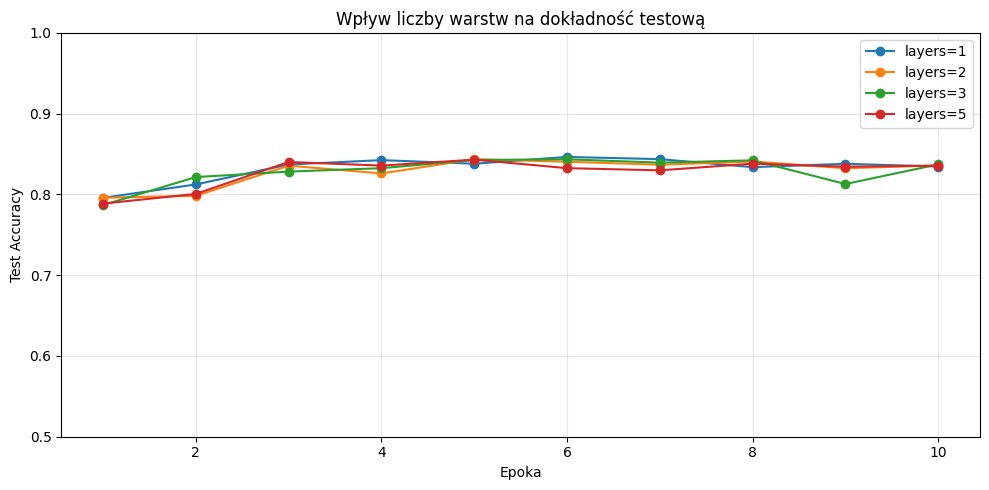


Finalne test acc:
  num_layers=1: 0.8345
  num_layers=2: 0.8359
  num_layers=3: 0.8372
  num_layers=5: 0.8356


In [23]:
layer_values = [1, 2, 3, 5]
results_layers = {}

for nl in layer_values:
    run = f'exp3_layers_{nl}'
    print(f'\n=== num_layers = {nl} (run: {run}) ===')
    m = DifferentialTransformerClassifier(
        vocab_size=VOCAB_SIZE, d_model=EMBED_DIM, num_diff_heads=4,
        dim_feedforward=256, num_layers=nl, dropout=0.1,
        max_len=MAX_LEN, lambda_init=0.05
    )
    print(f'  Parametrów: {sum(p.numel() for p in m.parameters()):,}')
    h = train_model(m, train_loader, test_loader, epochs=10, device=DEVICE, run_name=run)
    results_layers[nl] = h['test_acc']

fig, ax = plt.subplots(figsize=(10, 5))
for nl, accs in results_layers.items():
    ax.plot(range(1, len(accs)+1), accs, marker='o', label=f'layers={nl}')
ax.set_title('Wpływ liczby warstw na dokładność testową')
ax.set_xlabel('Epoka')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nFinalne test acc:')
for nl, accs in results_layers.items():
    print(f'  num_layers={nl}: {accs[-1]:.4f}')


### Eksperyment 4 — Vanilla Transformer vs Differential Transformer

Kluczowe porownanie: ta sama architektura, ten sam budzet parametrow, jedyna roznica to mechanizm uwagi.

Konfiguracja: Vanilla 8 glosic (ekwiwalent Diff 4 glosic — kazda Diff-glosica to 2 mapy).


In [24]:
# TransformerClassifier z Lab 10 (kopia)
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=8, dim_feedforward=256,
                 num_layers=3, dropout=0.1, max_len=500):
        super().__init__()
        self.cls_token    = nn.Parameter(torch.randn(1, 1, d_model))
        self.embedding    = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len+1, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Linear(d_model, 1)

    def forward(self, x, lengths=None):
        B = x.size(0)
        x   = self.embedding(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.pos_encoding(x)

        mask = None
        if lengths is not None:
            T = x.size(1)
            mask = torch.zeros(B, T, dtype=torch.bool, device=x.device)
            for i, l in enumerate(lengths):
                if l + 1 < T:
                    mask[i, l + 1:] = True

        out = self.transformer(x, src_key_padding_mask=mask)
        return self.classifier(out[:, 0, :]).squeeze(-1)


print('--- Vanilla Transformer (8 głowic) ---')
vanilla_model = TransformerClassifier(
    vocab_size=VOCAB_SIZE, d_model=EMBED_DIM,
    nhead=8, dim_feedforward=256, num_layers=3, dropout=0.1, max_len=MAX_LEN
)
print(f'Parametrów: {sum(p.numel() for p in vanilla_model.parameters()):,}')
history_vanilla = train_model(
    vanilla_model, train_loader, test_loader, epochs=20, device=DEVICE,
    run_name='exp4_vanilla'
)

print('\n--- Differential Transformer (4 głowice diff) ---')
diff_model_cmp = DifferentialTransformerClassifier(
    vocab_size=VOCAB_SIZE, d_model=EMBED_DIM,
    num_diff_heads=4, dim_feedforward=256, num_layers=3, dropout=0.1,
    max_len=MAX_LEN, lambda_init=0.05
)
print(f'Parametrów: {sum(p.numel() for p in diff_model_cmp.parameters()):,}')
history_diff_cmp = train_model(
    diff_model_cmp, train_loader, test_loader, epochs=10, device=DEVICE,
    run_name='exp4_differential'
)


--- Vanilla Transformer (8 głowic) ---
Parametrów: 5,819,649


/home/jedkociecki/repos/studia/ai/deep-neural-network-pwr/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/20 | loss: 0.5812 | train acc: 0.671 | test acc: 0.787
Epoch 2/20 | loss: 0.4008 | train acc: 0.819 | test acc: 0.829
Epoch 3/20 | loss: 0.3366 | train acc: 0.856 | test acc: 0.838
Epoch 4/20 | loss: 0.2848 | train acc: 0.886 | test acc: 0.841
Epoch 5/20 | loss: 0.2428 | train acc: 0.904 | test acc: 0.844
Epoch 6/20 | loss: 0.2110 | train acc: 0.919 | test acc: 0.842
Epoch 7/20 | loss: 0.1795 | train acc: 0.932 | test acc: 0.842
Epoch 8/20 | loss: 0.1541 | train acc: 0.943 | test acc: 0.842
Epoch 9/20 | loss: 0.1262 | train acc: 0.954 | test acc: 0.834
Epoch 10/20 | loss: 0.1164 | train acc: 0.959 | test acc: 0.826
Epoch 11/20 | loss: 0.0952 | train acc: 0.967 | test acc: 0.838
Epoch 12/20 | loss: 0.0825 | train acc: 0.972 | test acc: 0.790
Epoch 13/20 | loss: 0.0767 | train acc: 0.973 | test acc: 0.832
Epoch 14/20 | loss: 0.0659 | train acc: 0.978 | test acc: 0.817
Epoch 15/20 | loss: 0.0576 | train acc: 0.982 | test acc: 0.835
Epoch 16/20 | loss: 0.0583 | train acc: 0.980 | t

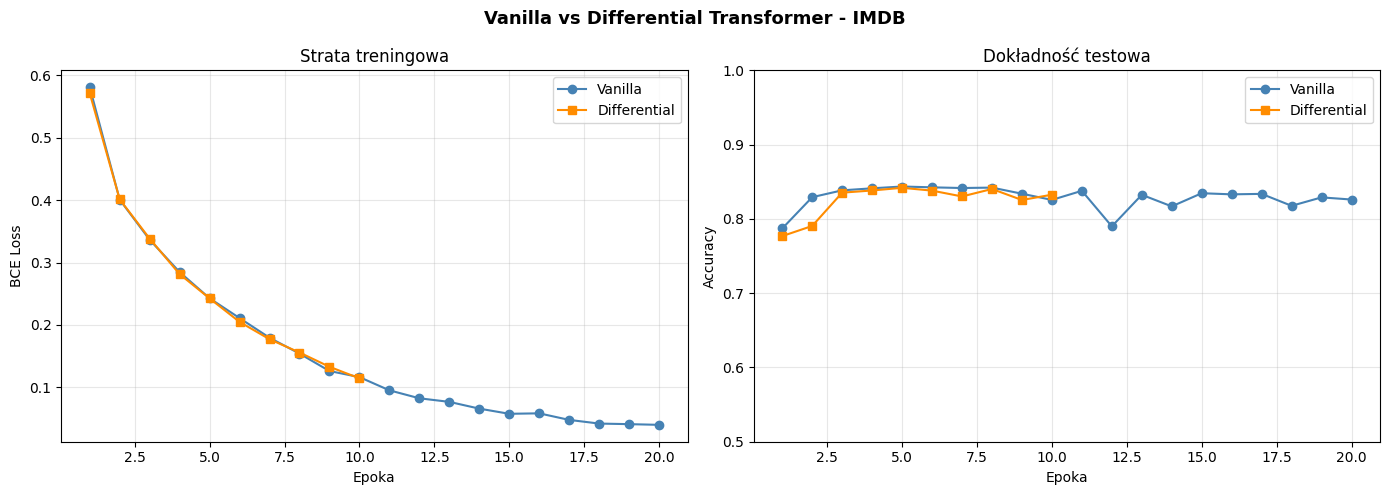

Vanilla finalne test acc:      0.8260
Differential finalne test acc: 0.8326


In [26]:
n_vanilla = len(history_vanilla['train_loss'])
n_diff    = len(history_diff_cmp['train_loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, n_vanilla+1), history_vanilla['train_loss'],  marker='o', color='steelblue',  label='Vanilla')
axes[0].plot(range(1, n_diff+1),   history_diff_cmp['train_loss'], marker='s', color='darkorange', label='Differential')
axes[0].set_title('Strata treningowa')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, n_vanilla+1), history_vanilla['test_acc'],  marker='o', color='steelblue',  label='Vanilla')
axes[1].plot(range(1, n_diff+1),   history_diff_cmp['test_acc'], marker='s', color='darkorange', label='Differential')
axes[1].set_title('Dokładność testowa')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Vanilla vs Differential Transformer - IMDB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Vanilla finalne test acc:      {history_vanilla["test_acc"][-1]:.4f}')
print(f'Differential finalne test acc: {history_diff_cmp["test_acc"][-1]:.4f}')


### Eksperyment 5 — Analiza wyuczonych wartosci lambda

Jedyna unikalnych cech Differential Attention jest wyuczalny parametr $\lambda$ per glosica. Po treningu mozemy sprawdzic co siec sie wyuczyla — czy rozne glosice specjalizuja sie w roznych stopniach tlumienia szumu?


Warstwa 0 - lambda per glosica: [0.1969 0.236  0.1712 0.1802]
Warstwa 1 - lambda per glosica: [0.1159 0.1201 0.1312 0.168 ]
Warstwa 2 - lambda per glosica: [0.3141 0.1306 0.1034 0.2602]


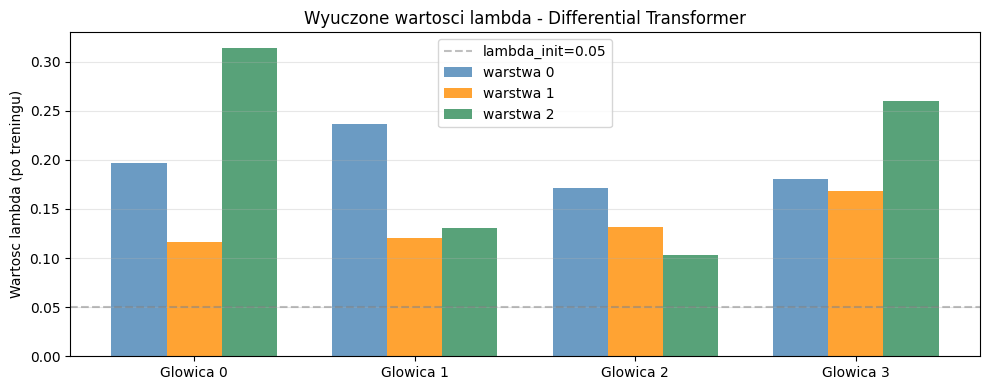

In [28]:
# Wyciagamy wyuczone lambda z kazdej warstwy diff_model_cmp
all_lambdas = {}
for layer_i, layer in enumerate(diff_model_cmp.layers):
    lam = layer.self_attn.lambda_.data.cpu().clamp(0, 1)
    all_lambdas[f'warstwa {layer_i}'] = lam.numpy()
    print(f'Warstwa {layer_i} - lambda per glosica: {lam.numpy().round(4)}')

fig, ax = plt.subplots(figsize=(10, 4))
n_heads = list(all_lambdas.values())[0].shape[0]
x_pos   = np.arange(n_heads)
width   = 0.25
colors  = ['steelblue', 'darkorange', 'seagreen']

for i, (name, lams) in enumerate(all_lambdas.items()):
    ax.bar(x_pos + i * width, lams, width, label=name, color=colors[i], alpha=0.8)

ax.set_xticks(x_pos + width)
ax.set_xticklabels([f'Glowica {i}' for i in range(n_heads)])
ax.set_ylabel('Wartosc lambda (po treningu)')
ax.set_title('Wyuczone wartosci lambda - Differential Transformer')
ax.axhline(0.05, color='grey', linestyle='--', alpha=0.5, label='lambda_init=0.05')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Wizualizacja map atencji

Porownanie jak wyglada uwaga w Vanilla Transformer vs Differential Transformer
na tym samym zdaniu z IMDB.

**Co bedziemy ogladac:**
- **Vanilla:** jedna mapa $A = \text{softmax}(QK^T/\sqrt{d})$ — zazwyczaj rozmyta,
  waga rozlana na wiele tokenow
- **Differential:** trzy mapy dla tej samej glosicy: $A_1$, $A_2$ i $A_{\text{diff}} = A_1 - \lambda A_2$
  — $A_1$ i $A_2$ sa podobne, ale po odjeciu szum sie kasuje i mapa staje sie bardziej 'spiky'

Dla czytelnosci pokazujemy uwage tokenu **[CLS]** na pozostale tokeny
(czyli wiersz 0 macierzy atencji) — to wlasnie ta uwaga jest uzywana do klasyfikacji.


### Przygotowanie — slownik i przykladowe zdanie

In [34]:
word_idx    = imdb.get_word_index(path='imdb_word_index.json')
idx_to_word = {v + 3: k for k, v in word_idx.items()}
idx_to_word[0] = '<PAD>'
idx_to_word[1] = '<START>'
idx_to_word[2] = '<OOV>'

def find_example(keyword, label, within=15):
    kid = word_idx.get(keyword, -1) + 3
    for seq, lbl in zip(x_test, y_test):
        if lbl == label and kid in seq[:within]:
            return seq
    return None

pos_seq = find_example('brilliant', label=1)
neg_seq = find_example('boring',    label=0)
print('POZYTYWNE:', [idx_to_word.get(i, '?') for i in pos_seq[:15]])
print('NEGATYWNE:', [idx_to_word.get(i, '?') for i in neg_seq[:15]])


POZYTYWNE: ['<START>', 'quai', 'des', 'directed', 'by', 'the', 'brilliant', 'henri', 'georges', 'clouzot', 'is', 'a', 'film', 'to', 'treasure']
NEGATYWNE: ['<START>', 'this', 'documentary', 'was', 'boring', 'and', 'quite', 'stupid', 'br', 'br', 'i', 'mean', 'the', 'documentary', 'maker']


### Ekstrakcja atencji — Vanilla Transformer

Uzywamy hooka na `self_attn` warstwy Vanilla — analogicznie do Lab 10.
PyTorch zwraca wagi atencji jako drugi element tupla z `MultiheadAttention`,
ale tylko gdy wywolamy z `need_weights=True` (domyslnie False w nowszych wersjach).


In [35]:
def get_vanilla_attention(model, sequence, layer_idx=0, max_words=30, device='cpu'):
    """Zwraca macierz atencji (T+1, T+1) dla warstwy layer_idx."""
    model.eval()
    seq_cut = sequence[:max_words]
    tokens  = ['[CLS]'] + [idx_to_word.get(i, '?') for i in seq_cut]
    x = torch.tensor([seq_cut], dtype=torch.long, device=device)

    captured = {}

    target_layer = model.transformer.layers[layer_idx]

    # Wymuszamy need_weights=True — bez tego PyTorch zwraca None
    original_forward = target_layer.self_attn.forward
    def patched_forward(*args, **kwargs):
        kwargs['need_weights']         = True
        kwargs['average_attn_weights'] = True   # srednia po glowicach
        return original_forward(*args, **kwargs)
    target_layer.self_attn.forward = patched_forward

    def hook(module, inp, out):
        # out = (output, attn_weights); attn_weights: (B, T, T)
        if out[1] is not None:
            captured['attn'] = out[1].detach().cpu()

    h = target_layer.self_attn.register_forward_hook(hook)

    with torch.no_grad():
        model(x)

    target_layer.self_attn.forward = original_forward
    h.remove()

    attn = captured.get('attn')  # (1, T+1, T+1)
    if attn is None:
        raise RuntimeError('Hook nie przechycil atencji — sprawdz need_weights')
    return tokens, attn[0]  # (T+1, T+1)


### Ekstrakcja atencji — Differential Transformer

Tutaj potrzebujemy trzech map: $A_1$, $A_2$ i $A_{\text{diff}}$.
Modyfikujemy `forward` klasy `DifferentialAttention` aby przy wlaczonej fladze
zapisywal mapy do zewnetrznego slownika.


In [36]:
def get_diff_attention(model, sequence, layer_idx=0, head_idx=0,
                       max_words=30, device='cpu'):
    """
    Zwraca (tokens, A1, A2, A_diff) dla wybranej warstwy i glosicy.
    Kazda macierz ma ksztalt (T+1, T+1).
    """
    model.eval()
    seq_cut = sequence[:max_words]
    tokens  = ['[CLS]'] + [idx_to_word.get(i, '?') for i in seq_cut]
    x = torch.tensor([seq_cut], dtype=torch.long, device=device)

    captured = {}

    target_attn = model.layers[layer_idx].self_attn
    original_forward = target_attn.forward

    def patched_forward(x_in, key_padding_mask=None):
        B, T, _ = x_in.shape
        h, dh, dq = target_attn.num_heads, target_attn.d_head, target_attn.d_half

        Q = target_attn.W_q(x_in).view(B, T, h, 2*dq).transpose(1, 2)
        K = target_attn.W_k(x_in).view(B, T, h, 2*dq).transpose(1, 2)
        V = target_attn.W_v(x_in).view(B, T, h, dh).transpose(1, 2)

        Q1, Q2 = Q[..., :dq], Q[..., dq:]
        K1, K2 = K[..., :dq], K[..., dq:]

        scale = target_attn.scale
        A1_raw = (Q1 @ K1.transpose(-2, -1)) * scale
        A2_raw = (Q2 @ K2.transpose(-2, -1)) * scale

        if key_padding_mask is not None:
            mask = key_padding_mask[:, None, None, :]
            A1_raw = A1_raw.masked_fill(mask, float('-inf'))
            A2_raw = A2_raw.masked_fill(mask, float('-inf'))

        A1 = torch.softmax(A1_raw, dim=-1)
        A2 = torch.softmax(A2_raw, dim=-1)
        lam = target_attn.lambda_.view(1, h, 1, 1).clamp(0, 1)
        A_diff = A1 - lam * A2

        # Zapisujemy wybrany head
        hi = head_idx
        captured['A1']     = A1[0, hi].detach().cpu()      # (T, T)
        captured['A2']     = A2[0, hi].detach().cpu()
        captured['A_diff'] = A_diff[0, hi].detach().cpu()
        captured['lambda'] = lam[0, hi, 0, 0].item()

        # Reszta forward bez zmian
        A_diff_drop = target_attn.attn_drop(A_diff)
        out = A_diff_drop @ V
        out = out.transpose(1, 2).contiguous().view(B, T, h * dh)
        out = target_attn.norm(out)
        return target_attn.W_o(out)

    target_attn.forward = patched_forward
    with torch.no_grad():
        model(x)
    target_attn.forward = original_forward

    return tokens, captured['A1'], captured['A2'], captured['A_diff'], captured['lambda']


### Funkcje rysowania

In [37]:
def plot_vanilla_attn(tokens, attn_matrix, title='Vanilla Attention', max_tok=20):
    """
    Rysuje macierz atencji jako heatmape.
    Podswietla wiersz CLS (indeks 0) — to uwaga uzywana do klasyfikacji.
    """
    n = min(len(tokens), max_tok)
    A = attn_matrix[:n, :n].numpy()
    toks = tokens[:n]

    fig, ax = plt.subplots(figsize=(max(8, n*0.45), max(7, n*0.4)))
    im = ax.imshow(A, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.03)

    ax.set_xticks(range(n)); ax.set_xticklabels(toks, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(toks, fontsize=8)

    # Podswietl wiersz CLS
    ax.add_patch(plt.Rectangle((-0.5, -0.5), n, 1, fill=False,
                               edgecolor='tomato', lw=2, label='wiersz CLS'))
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_diff_attn(tokens, A1, A2, A_diff, lam_val,
                  title='Differential Attention', max_tok=20):
    """
    Trzy heatmapy obok siebie: A1, A2, A_diff.
    Uzywa wspolnej skali vmin/vmax dla A1 i A2,
    osobnej dla A_diff (moze miec wartosci ujemne).
    """
    n = min(len(tokens), max_tok)
    a1   = A1[:n, :n].numpy()
    a2   = A2[:n, :n].numpy()
    adif = A_diff[:n, :n].numpy()
    toks = tokens[:n]

    vmax_ab = max(a1.max(), a2.max())
    vabs    = max(abs(adif.min()), abs(adif.max()))

    fig, axes = plt.subplots(1, 3, figsize=(max(18, n*1.3), max(6, n*0.4)))

    for ax, mat, ttl, cmap, vmi, vma in [
        (axes[0], a1,   f'A1 (softmax)',           'Blues',   0,      vmax_ab),
        (axes[1], a2,   f'A2 (softmax)',           'Blues',   0,      vmax_ab),
        (axes[2], adif, f'A_diff = A1 - {lam_val:.3f}*A2', 'RdBu_r', -vabs,  vabs),
    ]:
        im = ax.imshow(mat, cmap=cmap, vmin=vmi, vmax=vma, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(n)); ax.set_xticklabels(toks, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(n)); ax.set_yticklabels(toks, fontsize=7)
        # Ramka na wiersz CLS
        ax.add_patch(plt.Rectangle((-0.5, -0.5), n, 1, fill=False,
                                   edgecolor='tomato', lw=2))
        ax.set_title(ttl, fontsize=10, fontweight='bold')

    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_cls_row_comparison(tokens, vanilla_attn, A_diff, lam_val,
                            title='CLS attention: Vanilla vs Differential', max_tok=20):
    """
    Tylko wiersz CLS jako wykres slupkowy — latwiej zobaczyc roznice.
    """
    n    = min(len(tokens), max_tok)
    toks = tokens[:n]
    van  = vanilla_attn[0, :n].numpy()
    dif  = A_diff[0, :n].numpy()

    x = np.arange(n)
    w = 0.38
    fig, ax = plt.subplots(figsize=(max(12, n*0.6), 4))
    ax.bar(x - w/2, van,  w, label='Vanilla',      color='steelblue', alpha=0.85)
    ax.bar(x + w/2, dif,  w, label=f'Differential (lambda={lam_val:.3f})',
           color='darkorange', alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(toks, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Waga uwagi [CLS]')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


### Wizualizacja na przykladowych zdaniach

Uruchamiamy dla zdania pozytywnego i negatywnego, warstwa 0 i 2
(poczatkowa vs. gleboka), glosica 0.



POZYTYWNE | warstwa 0 | głowica 0


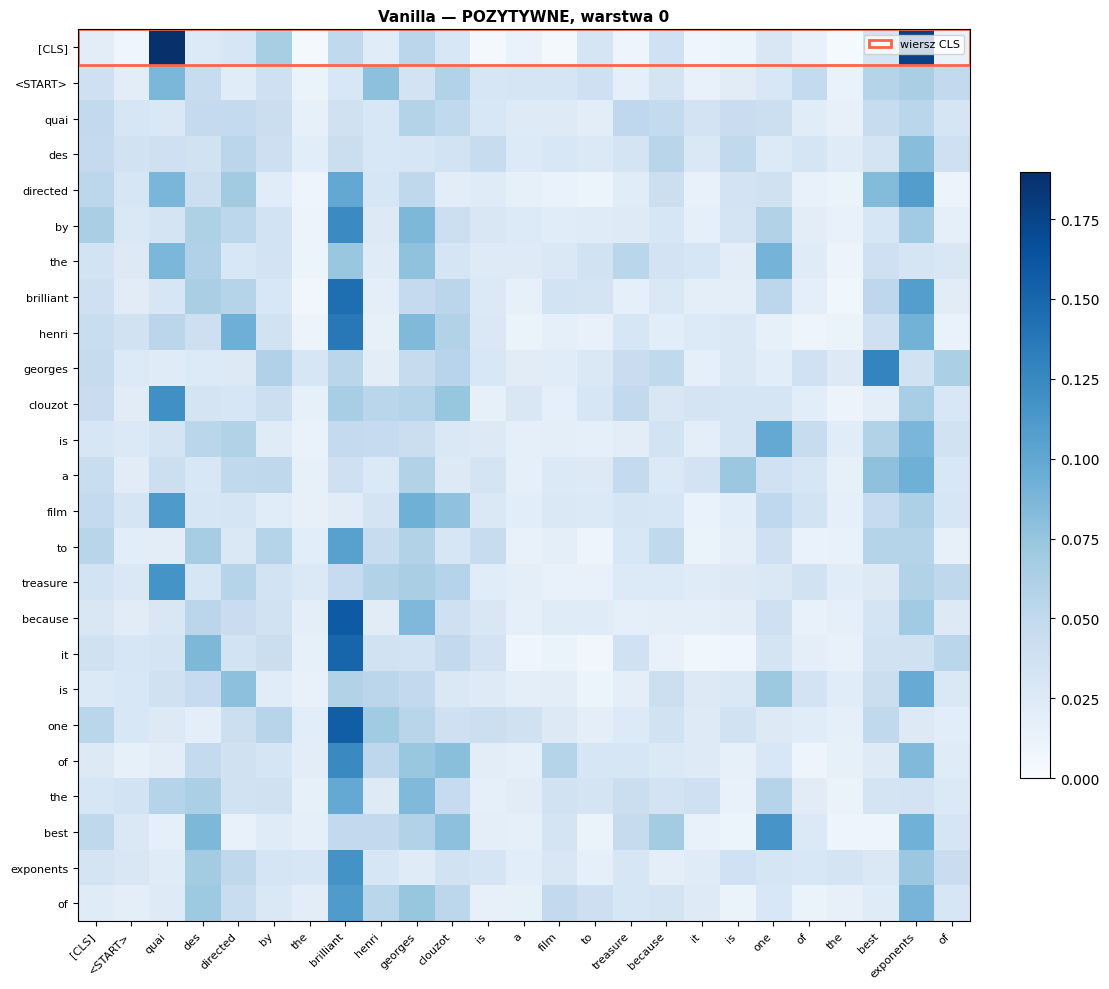

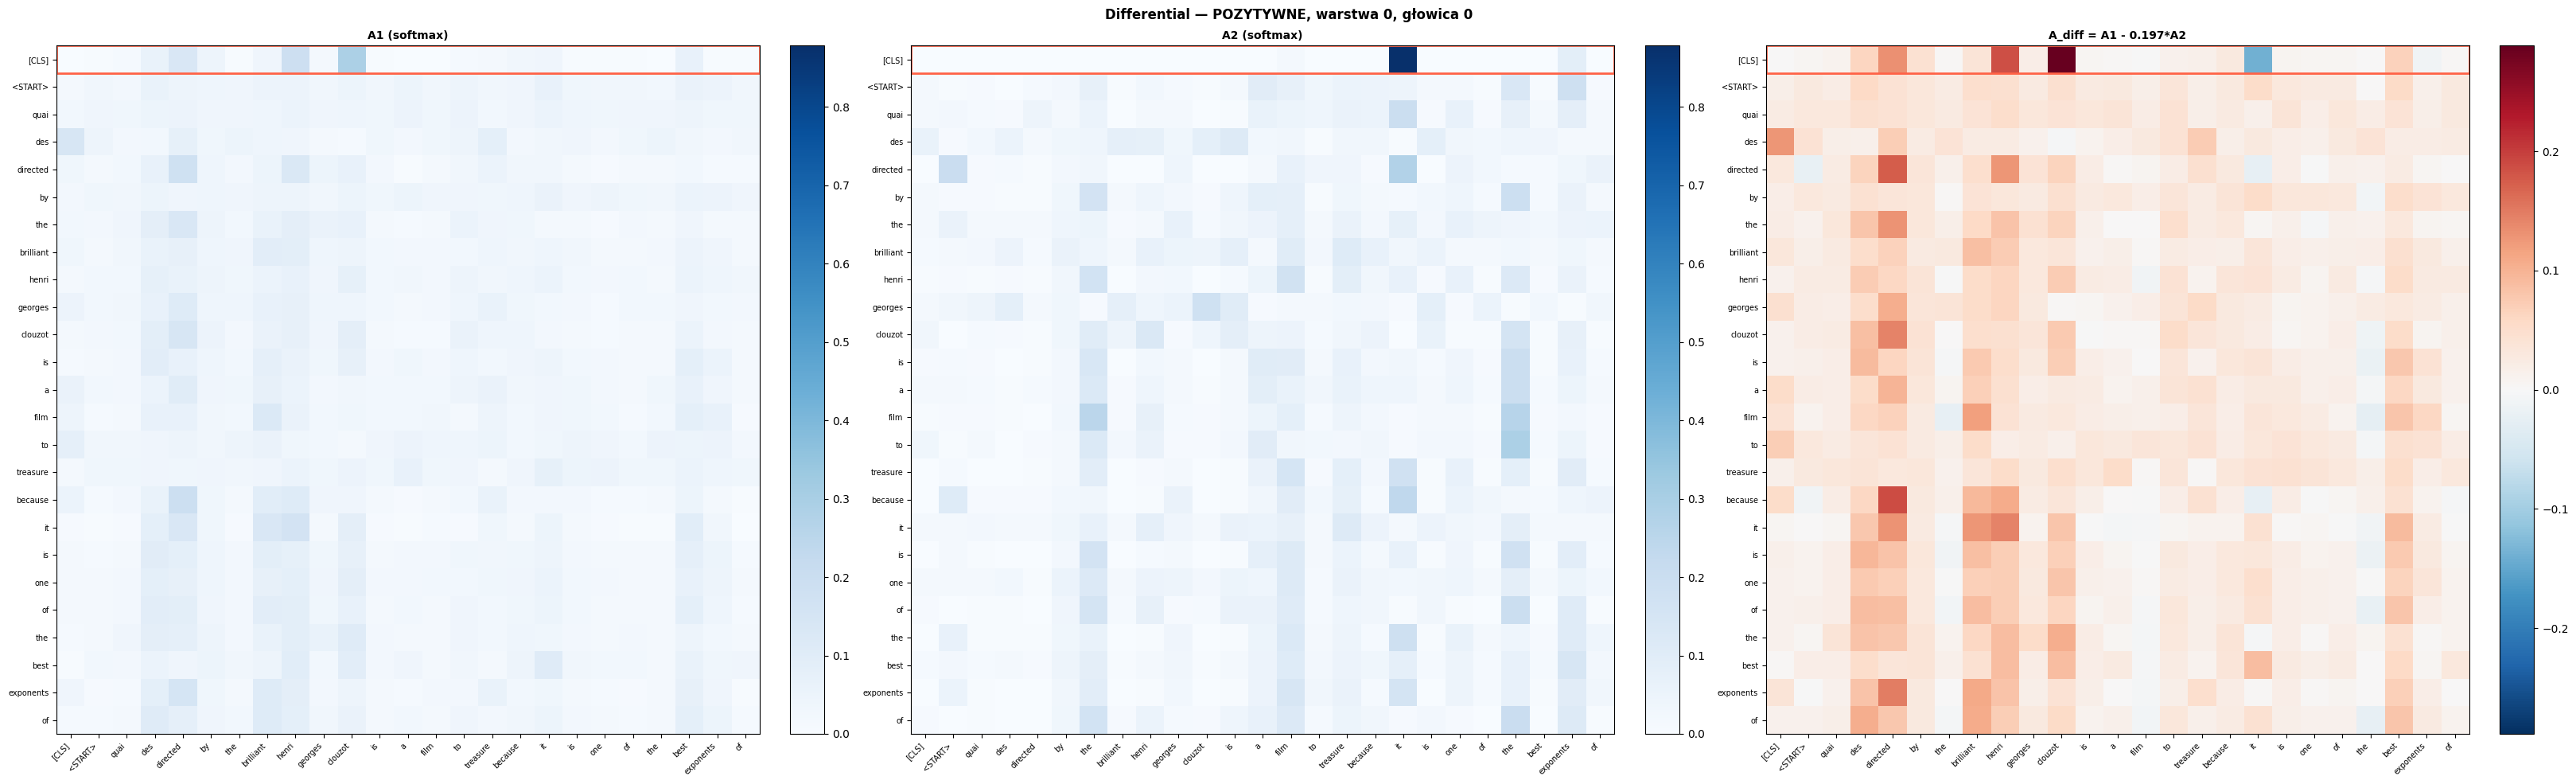

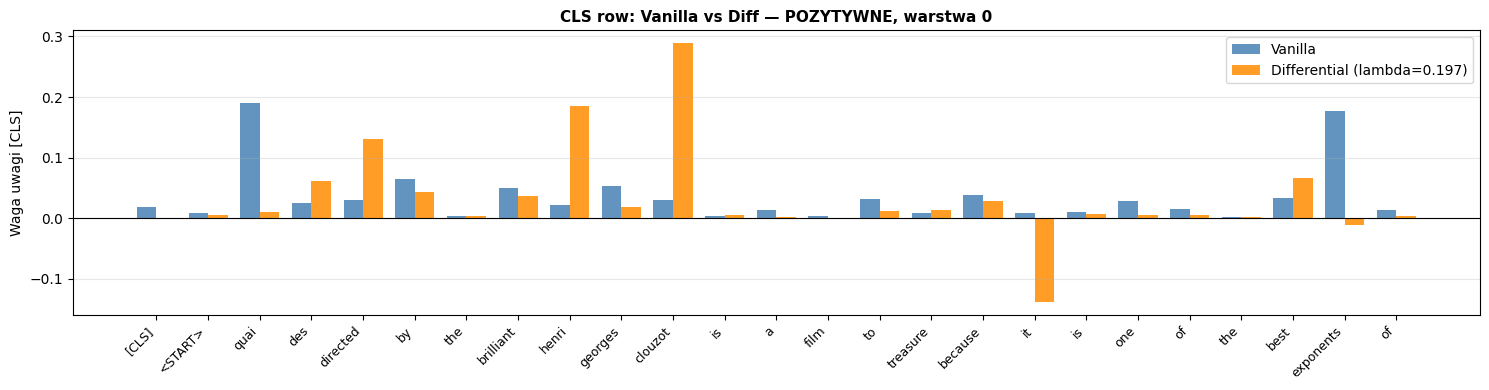


POZYTYWNE | warstwa 2 | głowica 0


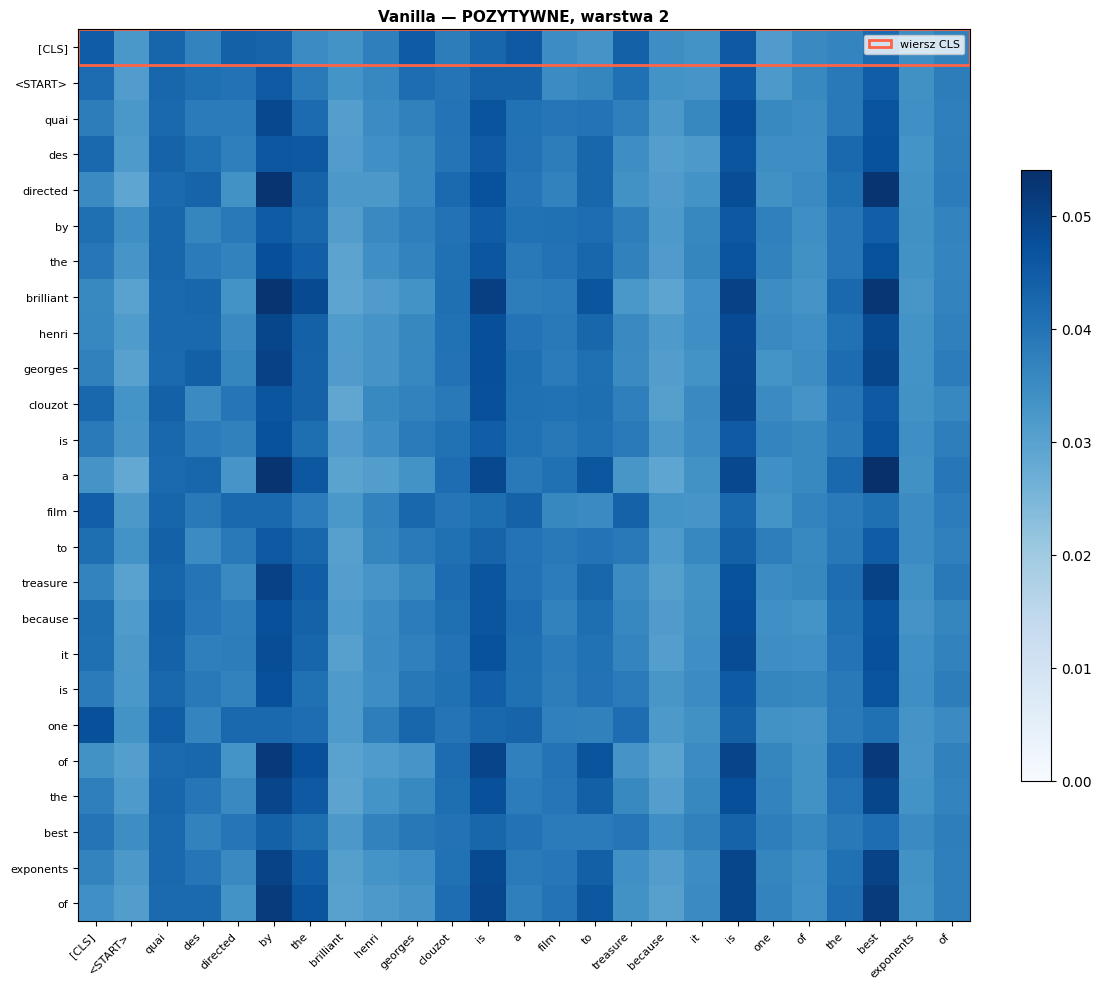

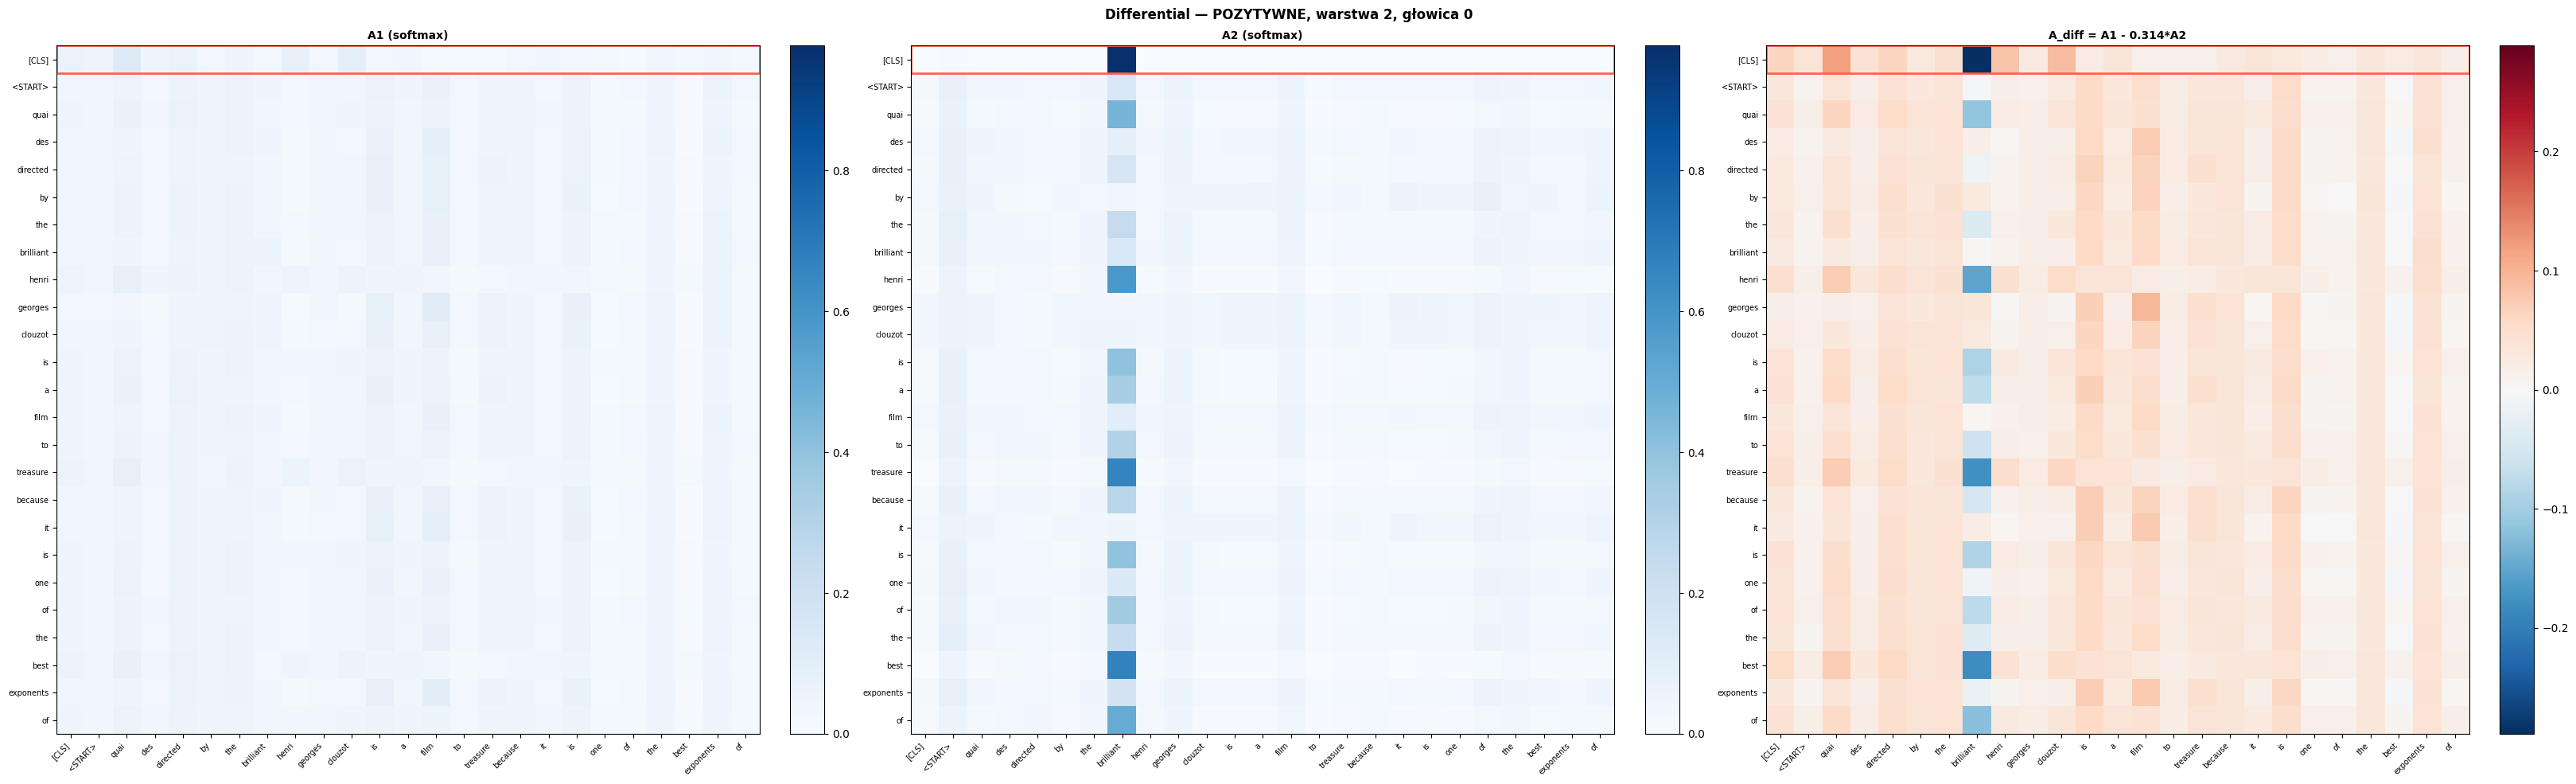

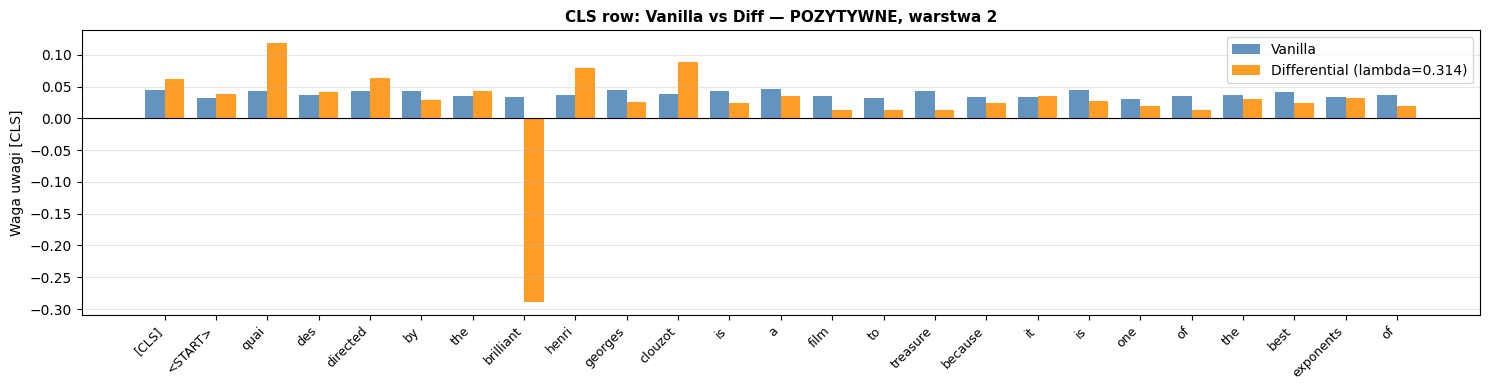


NEGATYWNE | warstwa 0 | głowica 0


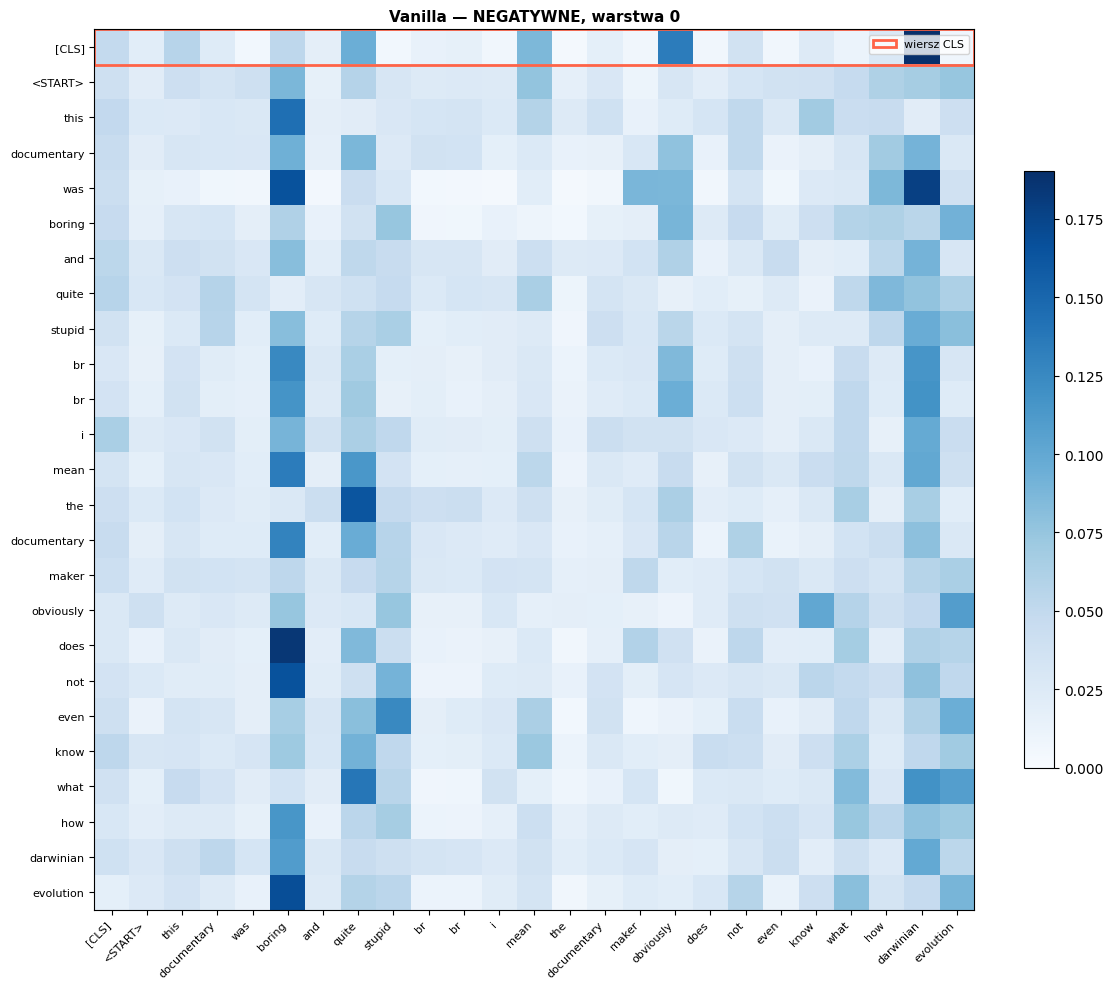

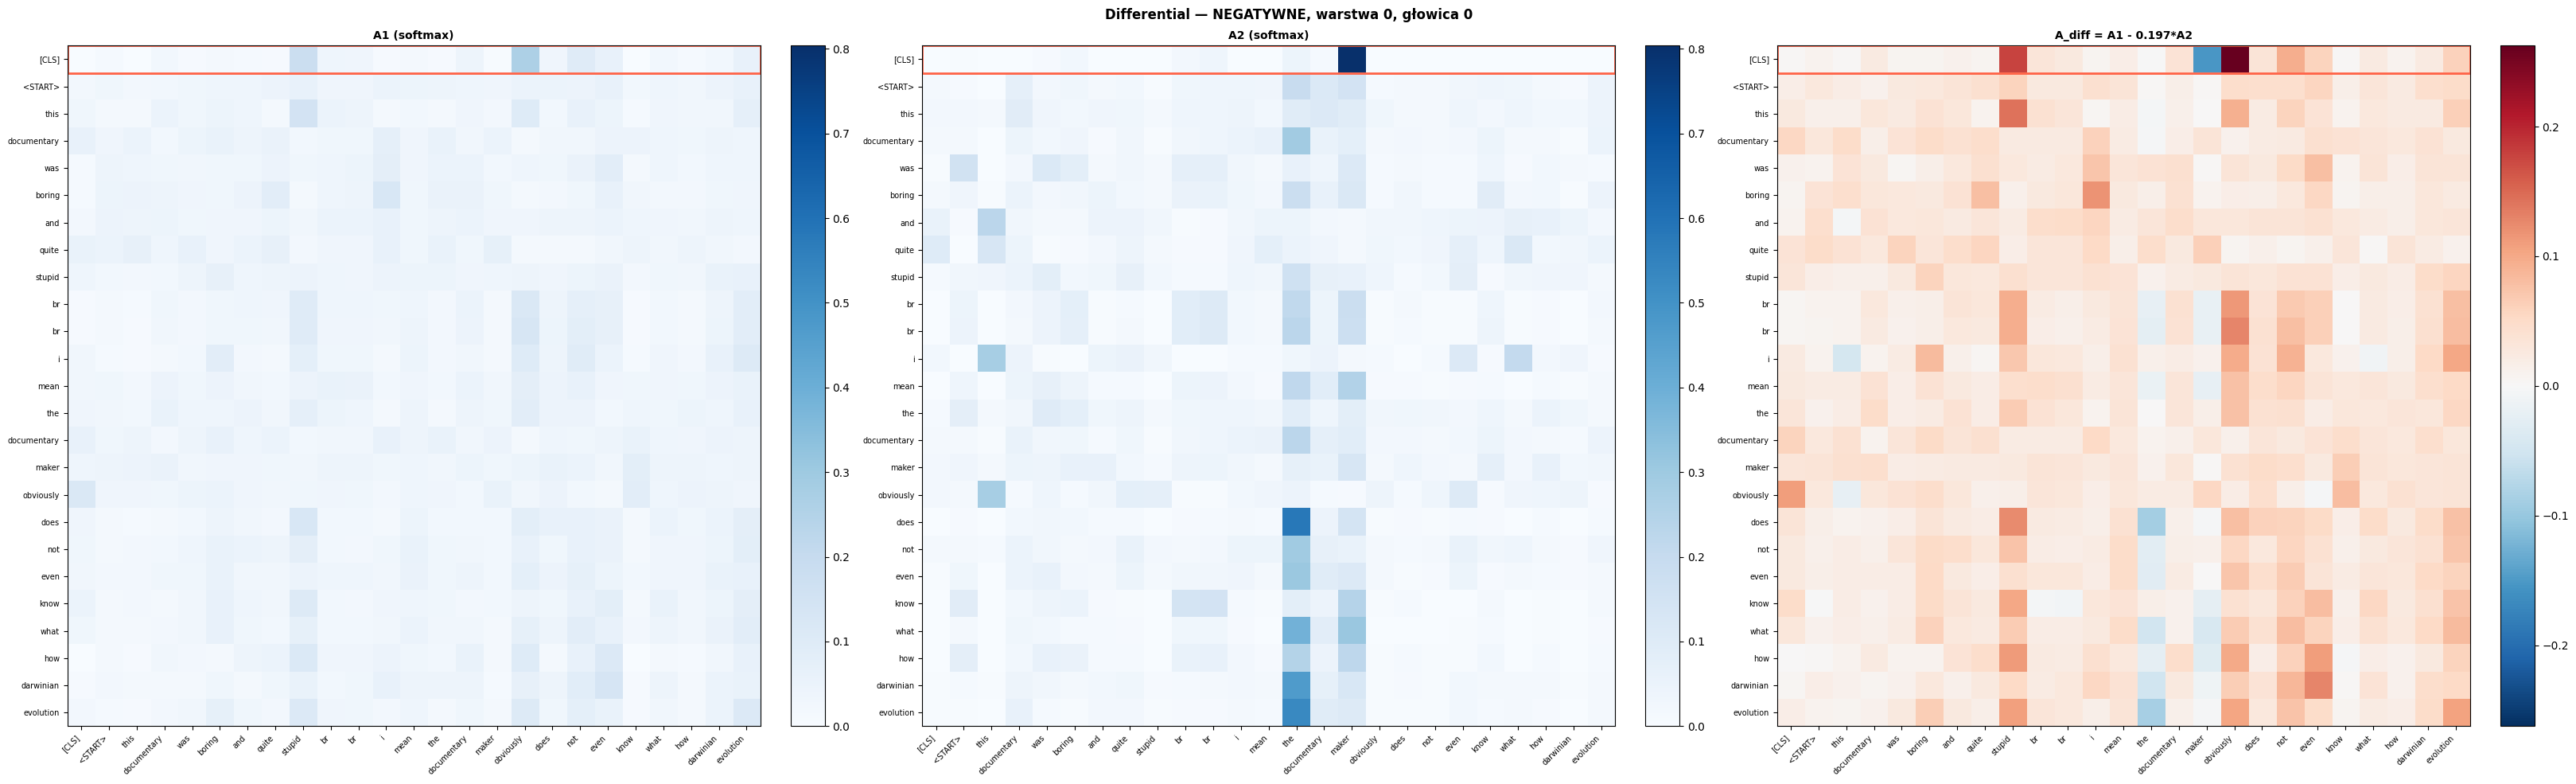

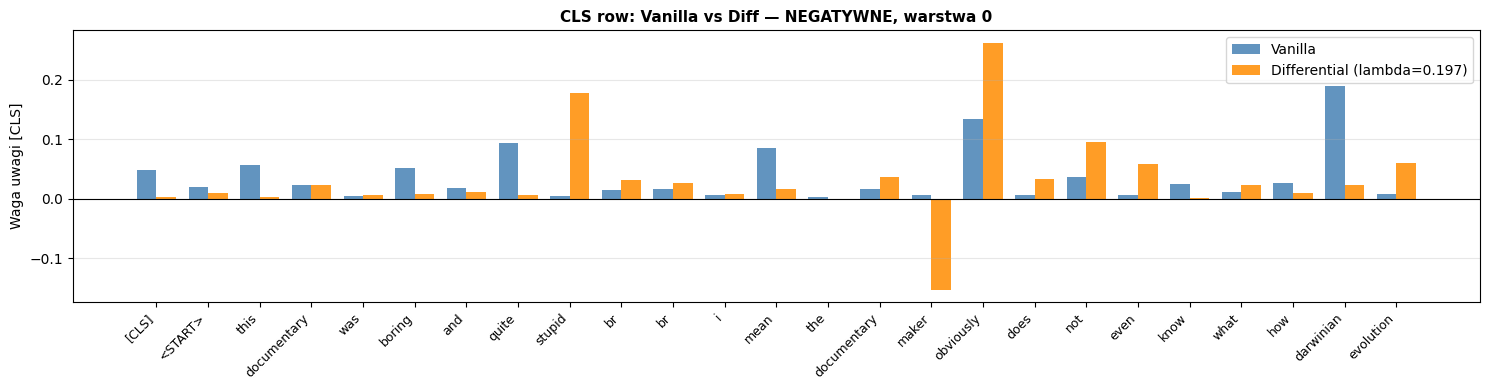


NEGATYWNE | warstwa 2 | głowica 0


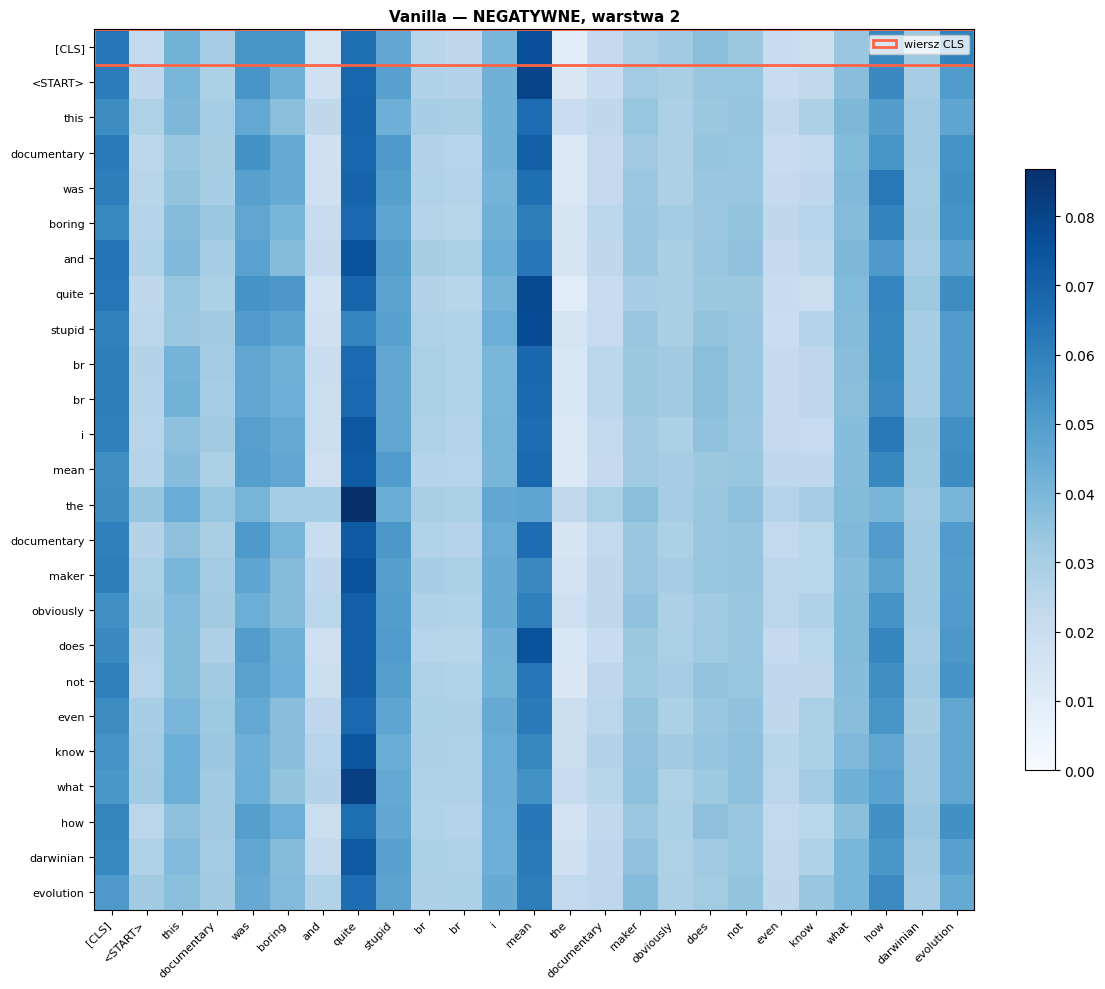

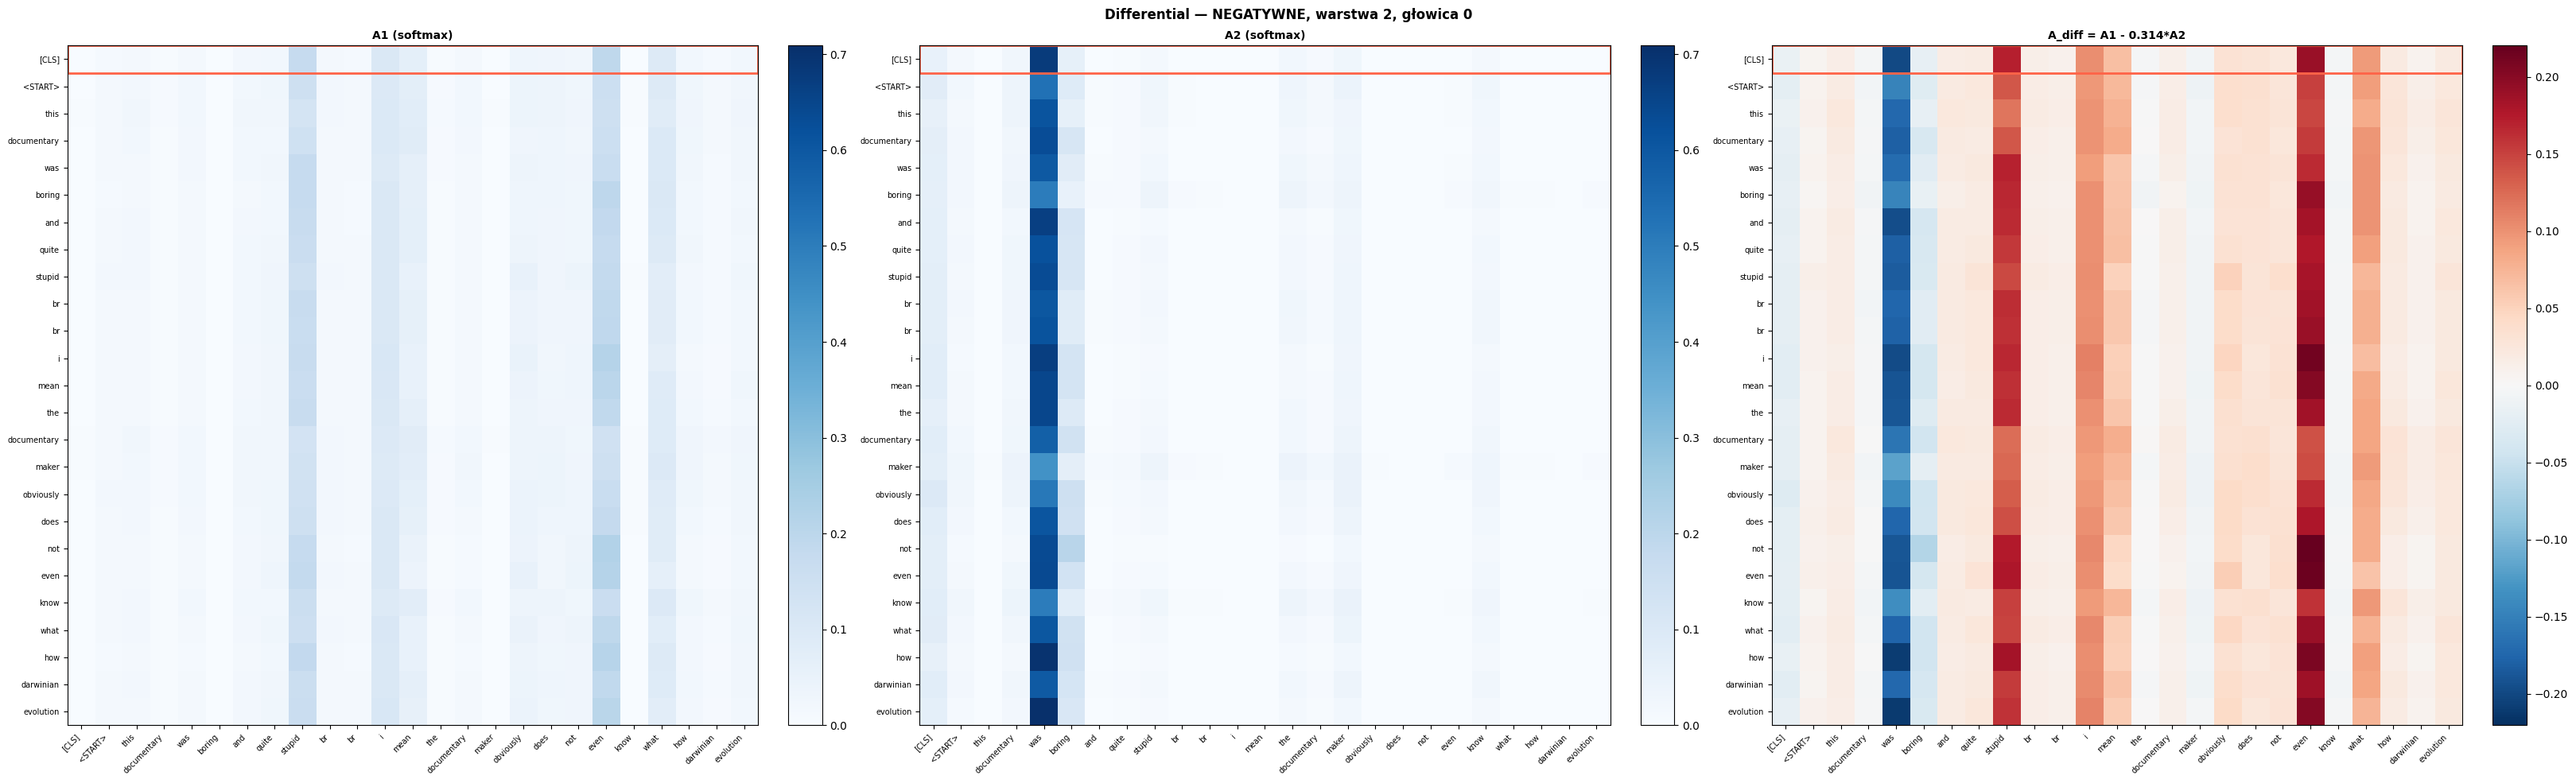

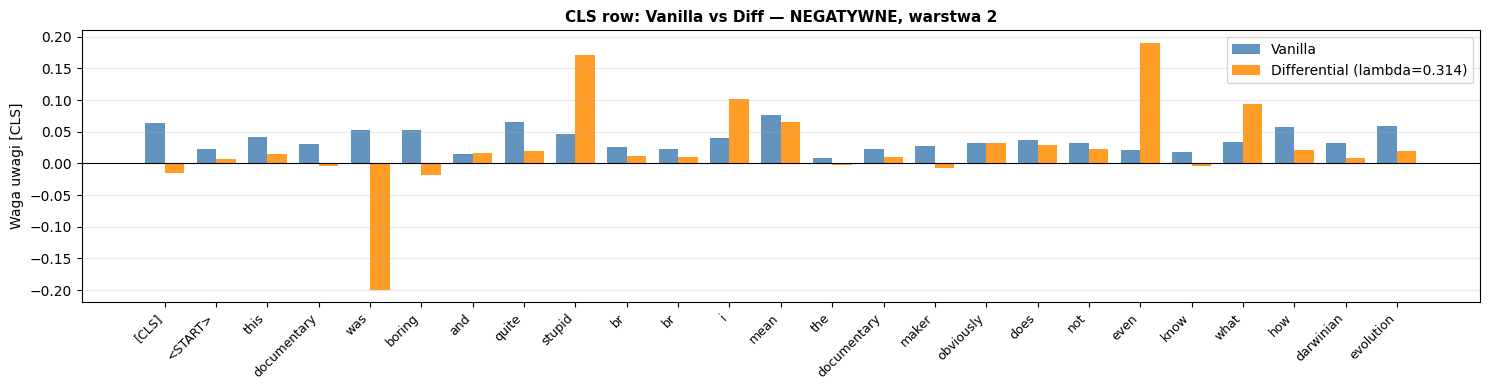

In [38]:
MAX_VIZ = 25   # ile tokenów pokazujemy
HEAD    = 0    # która głowica

sep = '=' * 60

for seq, label in [(pos_seq, 'POZYTYWNE'), (neg_seq, 'NEGATYWNE')]:
    for layer_idx in [0, 2]:
        print(f'\n{sep}')
        print(f'{label} | warstwa {layer_idx} | głowica {HEAD}')
        print(sep)

        # --- Vanilla ---
        toks_v, attn_v = get_vanilla_attention(
            vanilla_model, seq, layer_idx=layer_idx, max_words=MAX_VIZ, device=DEVICE
        )
        plot_vanilla_attn(
            toks_v, attn_v,
            title=f'Vanilla — {label}, warstwa {layer_idx}',
            max_tok=MAX_VIZ
        )

        # --- Differential ---
        toks_d, A1, A2, A_diff, lam = get_diff_attention(
            diff_model_cmp, seq, layer_idx=layer_idx,
            head_idx=HEAD, max_words=MAX_VIZ, device=DEVICE
        )
        plot_diff_attn(
            toks_d, A1, A2, A_diff, lam,
            title=f'Differential — {label}, warstwa {layer_idx}, głowica {HEAD}',
            max_tok=MAX_VIZ
        )

        # --- Porównanie wiersza CLS ---
        plot_cls_row_comparison(
            toks_d, attn_v, A_diff, lam,
            title=f'CLS row: Vanilla vs Diff — {label}, warstwa {layer_idx}',
            max_tok=MAX_VIZ
        )


### Co obserwowac na wizualizacjach?

**Heatmapy:**
- $A_1$ i $A_2$ wyglądają podobnie — obydwie sa rozmyte (softmax musi sumowac do 1)
- $A_{\text{diff}}$ jest **bardziej spiky** — kilka tokenow dostaje duza wage,
  reszta spada blisko zera lub ponizej zera (czerwone pola w RdBu)
- Wartosci ujemne w $A_{\text{diff}}$ oznaczaja tokeny aktywnie tlumione

**Wykresy slupkowe wiersza CLS:**
- Vanilla — waga rozlana dosc rownomiernie
- Differential — kilka tokenow wyraznie dominuje (slowa kluczowe dla sentymentu),
  reszta stlumiona

**Porownanie warstw 0 vs 2:**
- Warstwa 0 — uwaga dosc chaotyczna, model jeszcze 'nie wie' co wazne
- Warstwa 2 — uwaga wyraznie skupiona na slowach niosacych sentyment

To wlasnie jest to co autorzy nazywaja **noise cancellation** —
nie chodzi o eliminacje szumu z danych wejsciowych, tylko o to ze
uwaga sama w sobie przestaje byc 'rozmyta' i koncentruje sie na faktycznie
istotnych tokenach.


## 7. Wnioski

*(uzupelnij po uruchomieniu eksperymentow)*

Przykladowe pytania do analizy:
- Czy Differential Transformer osiaga lepsza lub porownywalna dokladnosc do Vanilla przy tej samej liczbie parametrow?
- Jaka wartosc `lambda_init` daje najlepsze wyniki? Czy `lambda_init=0.0` (degeneracja do vanilla) wypada gorzej?
- Czy wyuczone wartosci lambda roznia sie miedzy glowicami i warstwami? Co to sugeruje o specjalizacji glosic?
- Jak glebokosc modelu wplywa na skalowanie — czy Differential Transformer korzysta bardziej z dodatkowych warstw?
